In [ ]:
import numpy as np # linear algebra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler,OneHotEncoder, LabelEncoder
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA

from imblearn.under_sampling import RandomUnderSampler

In [ ]:
from google.colab import files
upload = files.upload()

Saving car_insurance_claim.csv to car_insurance_claim (1).csv


In [ ]:
df = pd.read_csv('car_insurance_claim.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10302 entries, 0 to 10301
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          10302 non-null  int64  
 1   KIDSDRIV    10302 non-null  int64  
 2   BIRTH       10302 non-null  object 
 3   AGE         10295 non-null  float64
 4   HOMEKIDS    10302 non-null  int64  
 5   YOJ         9754 non-null   float64
 6   INCOME      9732 non-null   object 
 7   PARENT1     10302 non-null  object 
 8   HOME_VAL    9727 non-null   object 
 9   MSTATUS     10302 non-null  object 
 10  GENDER      10302 non-null  object 
 11  EDUCATION   10302 non-null  object 
 12  OCCUPATION  9637 non-null   object 
 13  TRAVTIME    10302 non-null  int64  
 14  CAR_USE     10302 non-null  object 
 15  BLUEBOOK    10302 non-null  object 
 16  TIF         10302 non-null  int64  
 17  CAR_TYPE    10302 non-null  object 
 18  RED_CAR     10302 non-null  object 
 19  OLDCLAIM    10302 non-nul

Statistik data seperti nilai rata-rata, min dan max, dan standard deviasi

In [ ]:
df.describe()

,ID,KIDSDRIV,AGE,HOMEKIDS,YOJ,TRAVTIME,TIF,CLM_FREQ,MVR_PTS,CAR_AGE,CLAIM_FLAG
count,1.030200e+04,10302.000000,10295.000000,10302.000000,9754.000000,10302.000000,10302.000000,10302.000000,10302.000000,9663.000000,10302.000000
mean,4.956631e+08,0.169288,44.837397,0.720443,10.474062,33.416424,5.329159,0.800718,1.710153,8.298148,0.266550
std,2.864675e+08,0.506512,8.606445,1.116323,4.108943,15.869687,4.110795,1.154079,2.159015,5.714450,0.442177
min,6.317500e+04,0.000000,16.000000,0.000000,0.000000,5.000000,1.000000,0.000000,0.000000,-3.000000,0.000000
25%,2.442869e+08,0.000000,39.000000,0.000000,9.000000,22.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,4.970043e+08,0.000000,45.000000,0.000000,11.000000,33.000000,4.000000,0.000000,1.000000,8.000000,0.000000
75%,7.394551e+08,0.000000,51.000000,1.000000,13.000000,44.000000,7.000000,2.000000,3.000000,12.000000,1.000000
max,9.999264e+08,4.000000,81.000000,5.000000,23.000000,142.000000,25.000000,5.000000,13.000000,28.000000,1.000000


In [ ]:
df.head(10)

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,"$67,349",No,$0,z_No,...,Minivan,yes,"$4,461",2,No,3,$0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,"$91,449",No,"$257,252",z_No,...,Minivan,yes,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,"$52,881",No,$0,z_No,...,Van,yes,$0,0,No,2,$0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,"$16,039",No,"$124,191",Yes,...,z_SUV,no,"$38,690",2,No,3,$0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,NaN,No,"$306,251",Yes,...,Minivan,yes,$0,0,No,0,$0,6.0,0,Highly Urban/ Urban
5,743146596,0,17MAY49,50.0,0,NaN,"$114,986",No,"$243,925",Yes,...,z_SUV,no,"$19,217",2,Yes,3,$0,17.0,0,Highly Urban/ Urban
6,871024631,0,05MAY65,34.0,1,12.0,"$125,301",Yes,$0,z_No,...,Sports Car,no,$0,0,No,0,"$2,946",7.0,1,Highly Urban/ Urban
7,792300541,0,28FEB45,54.0,0,NaN,"$18,755",No,NaN,Yes,...,z_SUV,no,$0,0,No,0,$0,1.0,0,Highly Urban/ Urban
8,7945239,1,17SEP59,40.0,1,11.0,"$50,815",Yes,$0,z_No,...,Minivan,no,"$3,295",1,No,2,"$6,477",1.0,1,Highly Urban/ Urban
9,3577610,0,21AUG55,44.0,2,12.0,"$43,486",Yes,$0,z_No,...,z_SUV,no,$0,0,No,0,$0,10.0,0,z_Highly Rural/ Rural


In [ ]:
df.isna().sum()

ID              0
KIDSDRIV        0
BIRTH           0
AGE             7
HOMEKIDS        0
YOJ           548
INCOME        570
PARENT1         0
HOME_VAL      575
MSTATUS         0
GENDER          0
EDUCATION       0
OCCUPATION    665
TRAVTIME        0
CAR_USE         0
BLUEBOOK        0
TIF             0
CAR_TYPE        0
RED_CAR         0
OLDCLAIM        0
CLM_FREQ        0
REVOKED         0
MVR_PTS         0
CLM_AMT         0
CAR_AGE       639
CLAIM_FLAG      0
URBANICITY      0
dtype: int64

dataset mengandung banyak missing values dari beberapa variabel, sehingga tidak praktis untuk men-drop kolom-kolomnya dengan begitu saja. Untuk menangani missing values dalam dataset, maka perlu melakukan analisis dan penanganan data kategorikal dan numerik secara terpisah.

# **PRE-PROCESSING DATA**

---



Menghapus simbol $ dan mengganti tipe data dari object ke tipe data float

In [ ]:
cols = ['INCOME', 'HOME_VAL', 'OLDCLAIM', 'CLM_AMT', 'BLUEBOOK']

for col in cols:
        df[col] = df[col].str.replace(',', '').str.replace('$', '').astype('float')

<ipython-input-72-678ada053fb9>:4: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df[col] = df[col].str.replace(',', '').str.replace('$', '').astype('float')


Menghapus kolom yang datanya mengandung simbol _z

In [ ]:
for col in df.columns:
    if(df[col].dtype == "object"):
        df[col] = df[col].str.replace('z_', '')

In [ ]:
#Membuat Perhitungan dengan simpleimputer
rata2= df[['AGE', 'INCOME', 'HOME_VAL', 'BLUEBOOK']].copy()
modus= df[['YOJ', 'CAR_AGE' ]].copy()

imputer = SimpleImputer(strategy = 'mean')
imputer.fit(rata2)
rata2 = imputer.transform(rata2)

imputer = SimpleImputer(strategy = 'most_frequent')
imputer.fit(modus)
modus = imputer.transform(modus)

df[['AGE', 'INCOME', 'HOME_VAL', 'BLUEBOOK']]=rata2
df[['YOJ', 'CAR_AGE' ]]=modus

# Memeriksa missing values pada tipe data numerik
pd.DataFrame(df.isnull().sum()).T.style

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,OCCUPATION,TRAVTIME,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,0,0,0,0,0,0,0,0,0,0,0,0,665,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Memeriksa missing values pada tipe data kategorik
datakategorikal = df.select_dtypes(exclude=np.number).columns.tolist()
pd.DataFrame(df[datakategorikal].isnull().sum()).T.style

,BIRTH,PARENT1,MSTATUS,GENDER,EDUCATION,OCCUPATION,CAR_USE,CAR_TYPE,RED_CAR,REVOKED,URBANICITY
0,0,0,0,0,0,665,0,0,0,0,0


In [ ]:
imputer = SimpleImputer(strategy = 'most_frequent')
imputer.fit(df[datakategorikal])
df[datakategorikal] = imputer.transform(df[datakategorikal])

pd.DataFrame(df[datakategorikal].isnull().sum()).T.style

,BIRTH,PARENT1,MSTATUS,GENDER,EDUCATION,OCCUPATION,CAR_USE,CAR_TYPE,RED_CAR,REVOKED,URBANICITY
0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.head(10)

,ID,KIDSDRIV,BIRTH,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,...,CAR_TYPE,RED_CAR,OLDCLAIM,CLM_FREQ,REVOKED,MVR_PTS,CLM_AMT,CAR_AGE,CLAIM_FLAG,URBANICITY
0,63581743,0,16MAR39,60.0,0,11.0,67349.000000,No,0.000000,No,...,Minivan,yes,4461.0,2,No,3,0.0,18.0,0,Highly Urban/ Urban
1,132761049,0,21JAN56,43.0,0,11.0,91449.000000,No,257252.000000,No,...,Minivan,yes,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
2,921317019,0,18NOV51,48.0,0,11.0,52881.000000,No,0.000000,No,...,Van,yes,0.0,0,No,2,0.0,10.0,0,Highly Urban/ Urban
3,727598473,0,05MAR64,35.0,1,10.0,16039.000000,No,124191.000000,Yes,...,SUV,no,38690.0,2,No,3,0.0,10.0,0,Highly Urban/ Urban
4,450221861,0,05JUN48,51.0,0,14.0,61572.073263,No,306251.000000,Yes,...,Minivan,yes,0.0,0,No,0,0.0,6.0,0,Highly Urban/ Urban
5,743146596,0,17MAY49,50.0,0,12.0,114986.000000,No,243925.000000,Yes,...,SUV,no,19217.0,2,Yes,3,0.0,17.0,0,Highly Urban/ Urban
6,871024631,0,05MAY65,34.0,1,12.0,125301.000000,Yes,0.000000,No,...,Sports Car,no,0.0,0,No,0,2946.0,7.0,1,Highly Urban/ Urban
7,792300541,0,28FEB45,54.0,0,12.0,18755.000000,No,154523.018608,Yes,...,SUV,no,0.0,0,No,0,0.0,1.0,0,Highly Urban/ Urban
8,7945239,1,17SEP59,40.0,1,11.0,50815.000000,Yes,0.000000,No,...,Minivan,no,3295.0,1,No,2,6477.0,1.0,1,Highly Urban/ Urban
9,3577610,0,21AUG55,44.0,2,12.0,43486.000000,Yes,0.000000,No,...,SUV,no,0.0,0,No,0,0.0,10.0,0,Highly Rural/ Rural


Dapat dilihat di atas bahwa data sudah tidak ada simbol apapun sehingga bisa nantinya bisa dilakukan encoding.

# **Penyeimbangan data**

---



Kami akan melihat distribusi kelas target dan melihat berapa banyak yang mengajukan klaim vs jumlah yang tidak mengajukan klaim sehingga dapat dilihat apakah datanya seimbang atau tidak.

In [ ]:
for col in df.columns:
    if(df[col].dtype == "object"):
        df[col] = df[col].str.replace('z_', '')

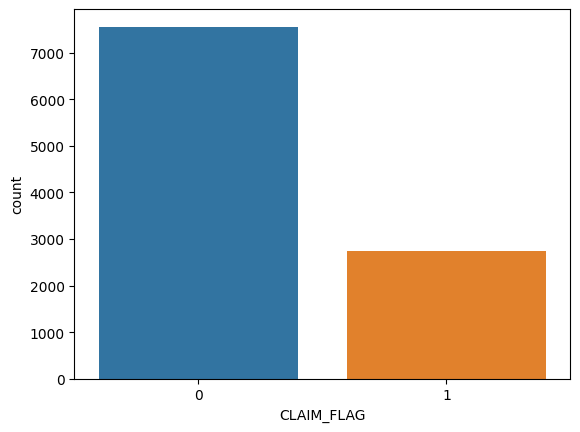

In [ ]:
sns.countplot(x=df['CLAIM_FLAG'], data=df)
plt.show()

Dapat dilihat bahwa jumlah pengguna asuransi yang belum mengajukan klaim, secara signifikan lebih tinggi daripada yang sudah mengajukan klaim. Hal ini dapat menyebabkan model machine learning menjadi bias terhadap kelas yang memiliki lebih banyak instansi ketika data tidak seimbang.

# **Memplot hubungan tiap data**

---



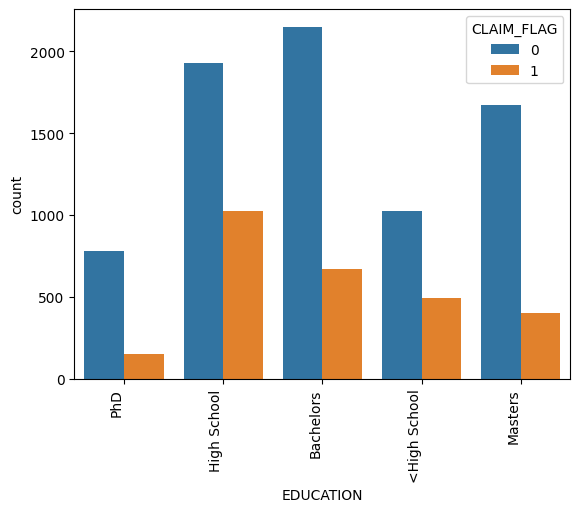

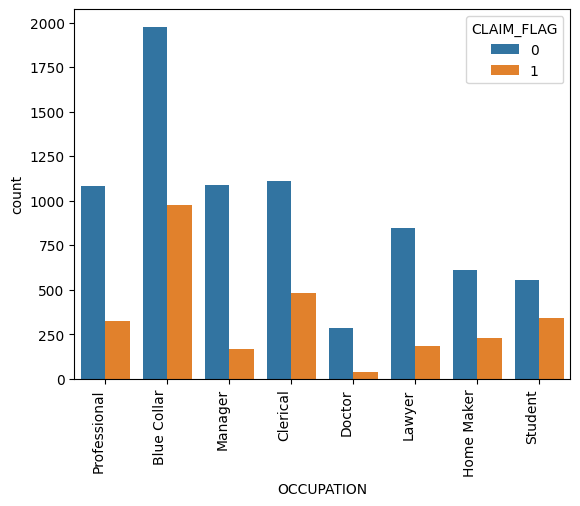

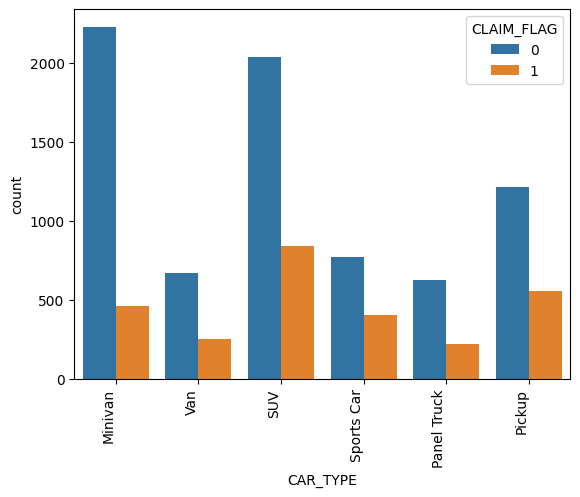

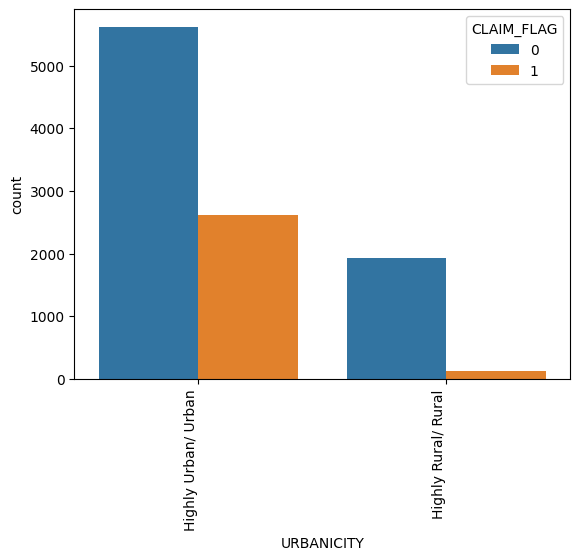

In [ ]:
colz = ['EDUCATION', 'OCCUPATION', 'CAR_TYPE', 'URBANICITY']

for col in colz:
    ax = sns.countplot(x=df[col], hue=df['CLAIM_FLAG'], data=df)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="right")
    plt.show()

# **Pemodelan**

---



In [ ]:
#Untuk menscaling serta meng-encoding data nantinya
scaler = StandardScaler()
encoder = LabelEncoder()

Membagi data untuk menghindari data leakage

In [ ]:
X = df.drop(['CLAIM_FLAG', 'ID', 'BIRTH', 'CLM_AMT', 'OLDCLAIM'], axis=1)
y = df['CLAIM_FLAG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12, shuffle=True)
X_train, X_holdout, y_train, y_holdout = train_test_split(X_train, y_train, test_size=0.1, random_state=42, shuffle=True)

In [ ]:
# 1. Mengubah X_train dan X_test ke dataframe untuk mencari mean dan modus
X_train = pd.DataFrame(X_train, columns=df.columns)
X_test = pd.DataFrame(X_test, columns=df.columns)

# 2. Mengdrop target feature
X_train.drop(['ID', 'CLAIM_FLAG', 'BIRTH', 'CLM_AMT', 'OLDCLAIM'], axis=1, inplace=True)
X_test.drop(['ID', 'CLAIM_FLAG', 'BIRTH', 'CLM_AMT', 'OLDCLAIM'], axis=1, inplace=True)

In [ ]:
X_train.head()

,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
2939,0,46.0,0,9.0,61572.073263,No,0.0,No,F,Masters,...,Private,11910.0,1,Sports Car,no,1,No,0,18.0,Highly Urban/ Urban
8265,0,61.0,1,8.0,19222.000000,Yes,0.0,No,F,High School,...,Commercial,25620.0,1,Pickup,no,4,No,5,6.0,Highly Rural/ Rural
5513,0,49.0,0,12.0,26217.000000,No,0.0,No,M,Masters,...,Private,12510.0,6,Minivan,yes,2,No,1,16.0,Highly Urban/ Urban
1820,0,51.0,0,8.0,74003.000000,No,249395.0,Yes,M,High School,...,Commercial,31780.0,1,Panel Truck,yes,0,No,0,10.0,Highly Rural/ Rural
2717,0,49.0,0,13.0,15492.000000,No,143129.0,Yes,F,<High School,...,Private,18950.0,7,Pickup,no,0,No,2,8.0,Highly Urban/ Urban


In [ ]:
# 3. Menscaling data tipe numerik
numeric_features = []

for col in X.columns:
    if(X[col].dtype == "float" or X[col].dtype == "int"):
        numeric_features.append(col)

X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.fit_transform(X_test[numeric_features])

# 4. Melakukan encoding pada data tipe kategorikal
categorical_features = X.select_dtypes(include=['object']).columns

for col in categorical_features:
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.fit_transform(X_test[col])

In [ ]:
X_train.head()

,KIDSDRIV,AGE,HOMEKIDS,YOJ,INCOME,PARENT1,HOME_VAL,MSTATUS,GENDER,EDUCATION,...,CAR_USE,BLUEBOOK,TIF,CAR_TYPE,RED_CAR,CLM_FREQ,REVOKED,MVR_PTS,CAR_AGE,URBANICITY
2939,-0.334675,0.141371,-0.648848,-0.388011,0.009228,0,-1.236209,0,0,3,...,1,-0.450635,-1.051678,4,0,0.166862,0,-0.797667,1.749540,1
8265,-0.334675,1.880184,0.242803,-0.637520,-0.913487,1,-1.236209,0,0,2,...,0,1.187307,-1.051678,2,0,2.757216,0,1.497296,-0.318171,0
5513,-0.334675,0.489134,-0.648848,0.360518,-0.761082,0,-1.236209,0,1,3,...,1,-0.378953,0.164782,0,1,1.030313,0,-0.338674,1.404921,1
1820,-0.334675,0.720975,-0.648848,-0.637520,0.280070,0,0.767701,1,1,2,...,0,1.923247,-1.051678,1,1,-0.696589,0,-0.797667,0.371066,0
2717,-0.334675,0.489134,-0.648848,0.610028,-0.994756,0,-0.086155,1,0,0,...,1,0.390438,0.408073,2,0,-0.696589,0,0.120318,0.026448,1


Melakukan undersampling terhadap data yang imbalanced (tidak seimbang)

In [ ]:
undersample = RandomUnderSampler(sampling_strategy='majority')

# undersampling
X_train_resampled, y_train_resampled = undersample.fit_resample(X_train, y_train)
X_test_resampled, y_test_resampled = undersample.fit_resample(X_test, y_test)

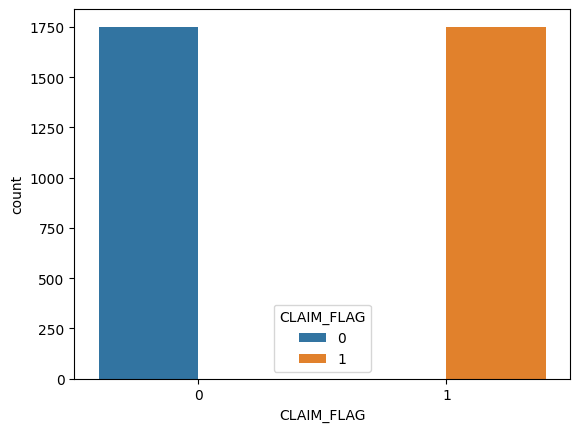

In [ ]:
sns.countplot(x=y_train_resampled, hue=y_train_resampled)
plt.show()

In [ ]:
selector = SelectKBest(mutual_info_classif, k=10)

X_new = selector.fit_transform(X_train_resampled, y_train_resampled)

selected_features_indices = selector.get_support(indices=True)
selected_features_names = X_train_resampled.columns[selected_features_indices]

X_train_resampled = X_train_resampled[selected_features_names]
X_test_resampled = X_test_resampled[selected_features_names]

In [ ]:
pca = PCA()
pca.fit(X_train_resampled)

# create range enumerating pca feats
features = range(pca.n_components_)

# **Membangun model logistic regression**

In [ ]:
model_logistic = LogisticRegression()
model_logistic.fit(X_train_resampled, y_train_resampled)

LogisticRegression()

In [ ]:
y_predicted_Logistic = model_logistic.predict(X_test_resampled)

In [ ]:
logistic_score = model_logistic.score(X_test_resampled, y_test_resampled)
logistic_score

0.7087912087912088

In [ ]:
print(classification_report(y_test_resampled, y_predicted_Logistic))

              precision    recall  f1-score   support

           0       0.72      0.69      0.70       819
           1       0.70      0.73      0.71       819

    accuracy                           0.71      1638
   macro avg       0.71      0.71      0.71      1638
weighted avg       0.71      0.71      0.71      1638



# **KNearest Neighbor**

---



**k = 3**

In [ ]:
KNN_model4 = KNeighborsClassifier(n_neighbors = 3)
KNN_model4.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
y_predicted_KNN4 = KNN_model4.predict(X_test_resampled)
KNN_Score4 = KNN_model4.score(X_test_resampled, y_test_resampled)
KNN_Score4

0.6538461538461539

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN4))

              precision    recall  f1-score   support

           0       0.65      0.68      0.66       819
           1       0.66      0.63      0.65       819

    accuracy                           0.65      1638
   macro avg       0.65      0.65      0.65      1638
weighted avg       0.65      0.65      0.65      1638



**K=5**

In [ ]:
KNN_model = KNeighborsClassifier(n_neighbors = 5)
KNN_model.fit(X_train_resampled, y_train_resampled)


KNeighborsClassifier()

In [ ]:
y_predicted_KNN = KNN_model.predict(X_test_resampled)
KNN_Score = KNN_model.score(X_test_resampled, y_test_resampled)
KNN_Score

0.6746031746031746

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN))

              precision    recall  f1-score   support

           0       0.67      0.68      0.68       819
           1       0.68      0.67      0.67       819

    accuracy                           0.67      1638
   macro avg       0.67      0.67      0.67      1638
weighted avg       0.67      0.67      0.67      1638



**K = 7**

In [ ]:
KNN_model2 = KNeighborsClassifier(n_neighbors = 7)
KNN_model2.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
y_predicted_KNN2 = KNN_model2.predict(X_test_resampled)
KNN_Score2 = KNN_model2.score(X_test_resampled, y_test_resampled)
KNN_Score2

0.6837606837606838

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN2))

              precision    recall  f1-score   support

           0       0.68      0.69      0.69       819
           1       0.69      0.67      0.68       819

    accuracy                           0.68      1638
   macro avg       0.68      0.68      0.68      1638
weighted avg       0.68      0.68      0.68      1638



**k = 9**

In [ ]:
KNN_model3 = KNeighborsClassifier(n_neighbors = 9)
KNN_model3.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=9)

In [ ]:
y_predicted_KNN3 = KNN_model3.predict(X_test_resampled)
KNN_Score3 = KNN_model3.score(X_test_resampled, y_test_resampled)
KNN_Score3

0.6825396825396826

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN3))

              precision    recall  f1-score   support

           0       0.68      0.69      0.69       819
           1       0.69      0.67      0.68       819

    accuracy                           0.68      1638
   macro avg       0.68      0.68      0.68      1638
weighted avg       0.68      0.68      0.68      1638



**K = 11**

In [ ]:
KNN_model5 = KNeighborsClassifier(n_neighbors = 11)
KNN_model5.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=11)

In [ ]:
y_predicted_KNN5 = KNN_model5.predict(X_test_resampled)
KNN_Score5 = KNN_model5.score(X_test_resampled, y_test_resampled)
KNN_Score5

0.6782661782661783

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN5))

              precision    recall  f1-score   support

           0       0.67      0.69      0.68       819
           1       0.68      0.67      0.67       819

    accuracy                           0.68      1638
   macro avg       0.68      0.68      0.68      1638
weighted avg       0.68      0.68      0.68      1638



**k = 13**

In [ ]:
KNN_model6 = KNeighborsClassifier(n_neighbors = 13)
KNN_model6.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=13)

In [ ]:
y_predicted_KNN6 = KNN_model6.predict(X_test_resampled)
KNN_Score6 = KNN_model6.score(X_test_resampled, y_test_resampled)
KNN_Score6

0.6874236874236874

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN6))

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       819
           1       0.69      0.68      0.68       819

    accuracy                           0.69      1638
   macro avg       0.69      0.69      0.69      1638
weighted avg       0.69      0.69      0.69      1638



**k = 15**

In [ ]:
KNN_model7 = KNeighborsClassifier(n_neighbors = 15)
KNN_model7.fit(X_train_resampled, y_train_resampled)

KNeighborsClassifier(n_neighbors=15)

In [ ]:
y_predicted_KNN7 = KNN_model7.predict(X_test_resampled)
KNN_Score7 = KNN_model7.score(X_test_resampled, y_test_resampled)
KNN_Score7

0.6874236874236874

In [ ]:
print(classification_report(y_test_resampled, y_predicted_KNN7))

              precision    recall  f1-score   support

           0       0.69      0.69      0.69       819
           1       0.69      0.68      0.69       819

    accuracy                           0.69      1638
   macro avg       0.69      0.69      0.69      1638
weighted avg       0.69      0.69      0.69      1638



Dapat dilihat bahwa algoritma logistic regression tingkat akurasinya lebih besar, sehingga model dengan metode ini kinerjanya lebih baik.

Accuracy score: 0.7087912087912088


              precision    recall  f1-score   support

           0       0.72      0.69      0.70       819
           1       0.70      0.73      0.71       819

    accuracy                           0.71      1638
   macro avg       0.71      0.71      0.71      1638
weighted avg       0.71      0.71      0.71      1638



Confusion Matrix:
[[566 253]
 [224 595]]


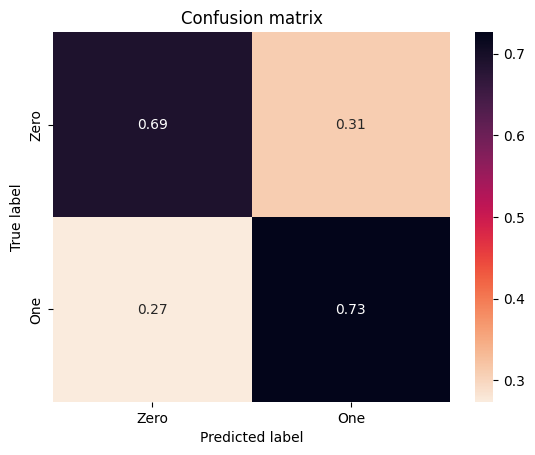

In [ ]:
logreg = LogisticRegression()

logreg.fit(X_train_resampled, y_train_resampled)

score = logreg.score(X_test_resampled, y_test_resampled)
y_pred = logreg.predict(X_test_resampled)
y_pred_proba = logreg.predict_proba(X_test_resampled)[:, 1]

importances = logreg.class_weight

print(f'Accuracy score: {score}')
print("\n")
print(classification_report(y_test_resampled, y_pred))
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_resampled, y_pred))


# memplot confusion matrix
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Zero', 'One']

cm = confusion_matrix(y_test_resampled, y_pred)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, cmap='rocket_r', xticklabels=categories, yticklabels=categories, fmt='.2f')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion matrix')
plt.show()

dengan perhitungan TP + TN = 548 + 599 = 1.147, ditunjukkan bahwa terdapat 1.147 prediksi yang benar. Dan dengan perhitungan FP + FN = 271 + 220 = 491, ditunjukkan bahwa terdapat prediksi yang salah sebanyak 491.



# **Cross-Validation terhadap Logistic Regression**

---



In [ ]:
from sklearn.model_selection import cross_val_score
#5 Fold
scores = cross_val_score(logreg, X_train_resampled, y_train_resampled, cv = 5, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores))

Cross-validation scores:[0.70613409 0.71754636 0.70571429 0.72285714 0.69142857]


In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores.mean()))

Average cross-validation score: 0.7087


In [ ]:
#10 Fold
scores2 = cross_val_score(logreg, X_train_resampled, y_train_resampled, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores2))

Cross-validation scores:[0.68945869 0.72079772 0.72285714 0.71428571 0.68857143 0.73714286
 0.73428571 0.71714286 0.66857143 0.69714286]


In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores2.mean()))

Average cross-validation score: 0.7090


In [ ]:
#20 Fold
scores3 = cross_val_score(logreg, X_train_resampled, y_train_resampled, cv = 20, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores3))

Cross-validation scores:[0.70454545 0.67045455 0.69714286 0.74285714 0.71428571 0.74285714
 0.72       0.70285714 0.68       0.72571429 0.72571429 0.73142857
 0.71428571 0.76571429 0.73142857 0.70285714 0.68571429 0.65714286
 0.65714286 0.73142857]


In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores3.mean()))

Average cross-validation score: 0.7102


# **Cross-Validation terhadap KNN**

---



K = 13

In [ ]:
#5 Fold
scores4 = cross_val_score(KNN_model6, X_train_resampled, y_train_resampled, cv = 5, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores4))

Cross-validation scores:[0.69044223 0.70613409 0.69428571 0.70142857 0.68      ]


In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores4.mean()))

Average cross-validation score: 0.6945


In [ ]:
#10 Fold
scores5 = cross_val_score(KNN_model6, X_train_resampled, y_train_resampled, cv = 10, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores5))

Cross-validation scores:[0.66951567 0.6980057  0.72857143 0.69142857 0.66571429 0.73142857
 0.69142857 0.71142857 0.65714286 0.68857143]


In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores5.mean()))

Average cross-validation score: 0.6933


In [ ]:
#20 Fold
scores6 = cross_val_score(KNN_model6, X_train_resampled, y_train_resampled, cv = 20, scoring='accuracy')

print('Cross-validation scores:{}'.format(scores6))

Cross-validation scores:[0.6875     0.65909091 0.69714286 0.70285714 0.74285714 0.72571429
 0.71428571 0.68571429 0.66285714 0.70285714 0.75428571 0.69142857
 0.65714286 0.70857143 0.75428571 0.70857143 0.68571429 0.68
 0.64       0.70285714]


In [ ]:
print('Average cross-validation score: {:.4f}'.format(scores6.mean()))

Average cross-validation score: 0.6982


K = 15

In [ ]:
#5 Fold
scores4 = cross_val_score(KNN_model7, X_train_resampled, y_train_resampled, cv = 5, scoring='accuracy')
print('Average cross-validation score: {:.4f}'.format(scores4.mean()))

Average cross-validation score: 0.6930


In [ ]:
#10 Fold
scores4 = cross_val_score(KNN_model7, X_train_resampled, y_train_resampled, cv = 10, scoring='accuracy')
print('Average cross-validation score: {:.4f}'.format(scores4.mean()))

Average cross-validation score: 0.6945


In [ ]:
#20 Fold
scores4 = cross_val_score(KNN_model7, X_train_resampled, y_train_resampled, cv = 20, scoring='accuracy')
print('Average cross-validation score: {:.4f}'.format(scores4.mean()))

Average cross-validation score: 0.6950


**Validasi model dengan cross validation menunjukkan bahwa tingkat akurasi model logistic regression lebih baik 1,7% dari model sebelumnya**

# **Kesimpulan**


---
Nilai hasil dari perhitungan dan pengujian akurasi dengan metode Logistic Regression adalah sebesar 71,7%. Nilai akurasi tersebut lebih besar dari metode KNN yang berkisar 68%. Walaupun kedua metode tersebut tidak memiliki selisih nilai akurasi yang besar, namun berbedaannya memiliki pengaruh yang signifikan terhadap model untuk rekomendasi pengambilan klaim asuransi bagi pengendara mobil. Sehingga, kinerja model dengan metode Logistic Regression lebih baik dari metode K-Nearest Neighbour.
